<center><span style="color:#27A3F5;font-size:26px;font-weight:700">Rent price prediction in Berlin</span></center>

<span style="color:#609926;font-size:20px;font-weight:500">Modeling and predictions</span>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [2]:
df = pd.read_csv('../datasets/rent_listings_final.csv')
df.shape

(15601, 22)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15601 entries, 0 to 15600
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   listing_url           15601 non-null  object 
 1   cold_rent             15601 non-null  float64
 2   area                  15601 non-null  float64
 3   rooms                 15601 non-null  float64
 4   floor                 13659 non-null  float64
 5   free_from             15601 non-null  object 
 6   has_balkon            15601 non-null  bool   
 7   has_terrasse          15601 non-null  bool   
 8   has_garten            15601 non-null  bool   
 9   elevator              15601 non-null  bool   
 10  parking               15601 non-null  bool   
 11  has_basement          15601 non-null  bool   
 12  is_barrier-free       15601 non-null  bool   
 13  has_built-in_kitchen  15601 non-null  bool   
 14  has_bathtub           15601 non-null  bool   
 15  has_shower         

In [4]:
# So we get reproducable results:
np.random.seed(16)

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 1: Feature Engineering</span>

<span style="font-weight:500">
1. Split the dataset into a train set (80%) and a test set (20%).
</span>

In [5]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["cold_rent", "listing_url"])
y = df["cold_rent"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

<span style="font-weight:500">
2. Encoding categorical variables.
</span>

In [6]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

In [7]:
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [8]:
feature_names = X_train.columns.tolist()

In [9]:
len(feature_names)

93

<span style="font-weight:500">
93 features for 15601 samples are not too many features.
</span>

<span style="font-weight:500">
3. Scaling the data.
</span>

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 2: Modeling and model evaluation</span>

<span style="font-weight:500">
1. Modeling and training
</span>

In [11]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LinearRegression())
])

rmse_scores = cross_val_score(pipeline, X_train, y_train, scoring="neg_mean_squared_error", cv=10)

mae_scores = cross_val_score(pipeline, X_train, y_train, scoring="neg_mean_absolute_error", cv=10)

r2_scores = cross_val_score(pipeline, X_train, y_train, scoring="r2", cv=10)

print("RMSE:", np.sqrt(-rmse_scores.mean()))
print("MAE:", -mae_scores.mean())
print("R2:", r2_scores.mean())

RMSE: 431.52294225249767
MAE: 291.25321240316003
R2: 0.6586293404895679


<span style="font-weight:500">
Linear regression performed with an R score of 0.658 which is not very good, but we cannot expect a simple model to capture all the trends with such a huge dataset. </span>

In [11]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(include_bias=False)),
    ("model", Ridge())
])

param_grid = {
    "poly__degree": [1, 2],
    "model__alpha": [0.01, 0.1, 1.0, 10.0]
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("CV RMSE:", np.sqrt(-grid.best_score_))

y_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)
print("Test MAE:", test_mae)

Best parameters: {'model__alpha': 10.0, 'poly__degree': 2}
CV RMSE: 373.1340218336258
Test RMSE: 334.63324642399056
Test R2: 0.7923459250139335
Test MAE: 201.5778182347564


<span style="font-weight:500">
A polynomial of 2nd degree performs better, much better, than the linear model, but with an R-squared of 0.792 this is definitely far from the best model we could use. </span>

In [12]:
from sklearn.neighbors import KNeighborsRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", KNeighborsRegressor(algorithm="ball_tree"))
])

param_grid = {
    "model__n_neighbors": [3, 5],
    "model__weights": ["distance"],
}

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("CV RMSE:", np.sqrt(-grid.best_score_))

y_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)
print("Test MAE:", test_mae)

Best parameters: {'model__n_neighbors': 3, 'model__weights': 'distance'}
CV RMSE: 334.1973123520061
Test RMSE: 312.8973176500452
Test R2: 0.8184459401555682
Test MAE: 165.6691937740411


<span style="font-weight:500">
KNN performs slightly better, but not good enough to be considered our final model. </span>

In [16]:
from sklearn.svm import SVR
from sklearn.model_selection import RandomizedSearchCV

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", SVR())
])

param_grid_svr = [
    {"model__kernel": ["linear"], "model__C": [0.1, 1, 10]},
    {"model__kernel": ["rbf"], "model__C": [1, 10, 100], "model__gamma": ["scale", "auto"]},
    {"model__kernel": ["poly"], "model__C": [1, 10], "model__gamma": ["scale"], "model__degree": [2, 3]},
]

grid = RandomizedSearchCV(
    pipeline,
    param_grid_svr,
    n_iter=10,  # we only try 10 random combos instead of all
    cv=4,
    scoring="neg_mean_squared_error",
    n_jobs=-1,
    random_state=42
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("CV RMSE:", np.sqrt(-grid.best_score_))

y_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)
print("Test MAE:", test_mae)

Best parameters: {'model__kernel': 'rbf', 'model__gamma': 'auto', 'model__C': 100}
CV RMSE: 411.75446404469386
Test RMSE: 381.8233677760727
Test R2: 0.7296494282005865
Test MAE: 224.70776244182488


In [20]:
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", RandomForestRegressor())
])

param_grid_rf = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__max_depth": [None, 10, 20, 30, 40],
    "model__min_samples_split": [2, 5, 10, 20],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__max_features": ["sqrt", "log2"],
}

grid = GridSearchCV(
    pipeline,
    param_grid_rf,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best parameters:", grid.best_params_)
print("CV RMSE:", np.sqrt(-grid.best_score_))

y_pred = best_model.predict(X_test)

test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
test_r2 = r2_score(y_test, y_pred)
test_mae = mean_absolute_error(y_test, y_pred)

print("Test RMSE:", test_rmse)
print("Test R2:", test_r2)
print("Test MAE:", test_mae)

Best parameters: {'model__max_depth': 40, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 400}
CV RMSE: 232.59543244821896
Test RMSE: 214.55694132162282
Test R2: 0.9146335103228163
Test MAE: 125.15653759484364


<span style="font-weight:500">
We got a good R squared of 0.914 and lower errors. This is the best model so far. We should aim for a higher R-squared. </span>

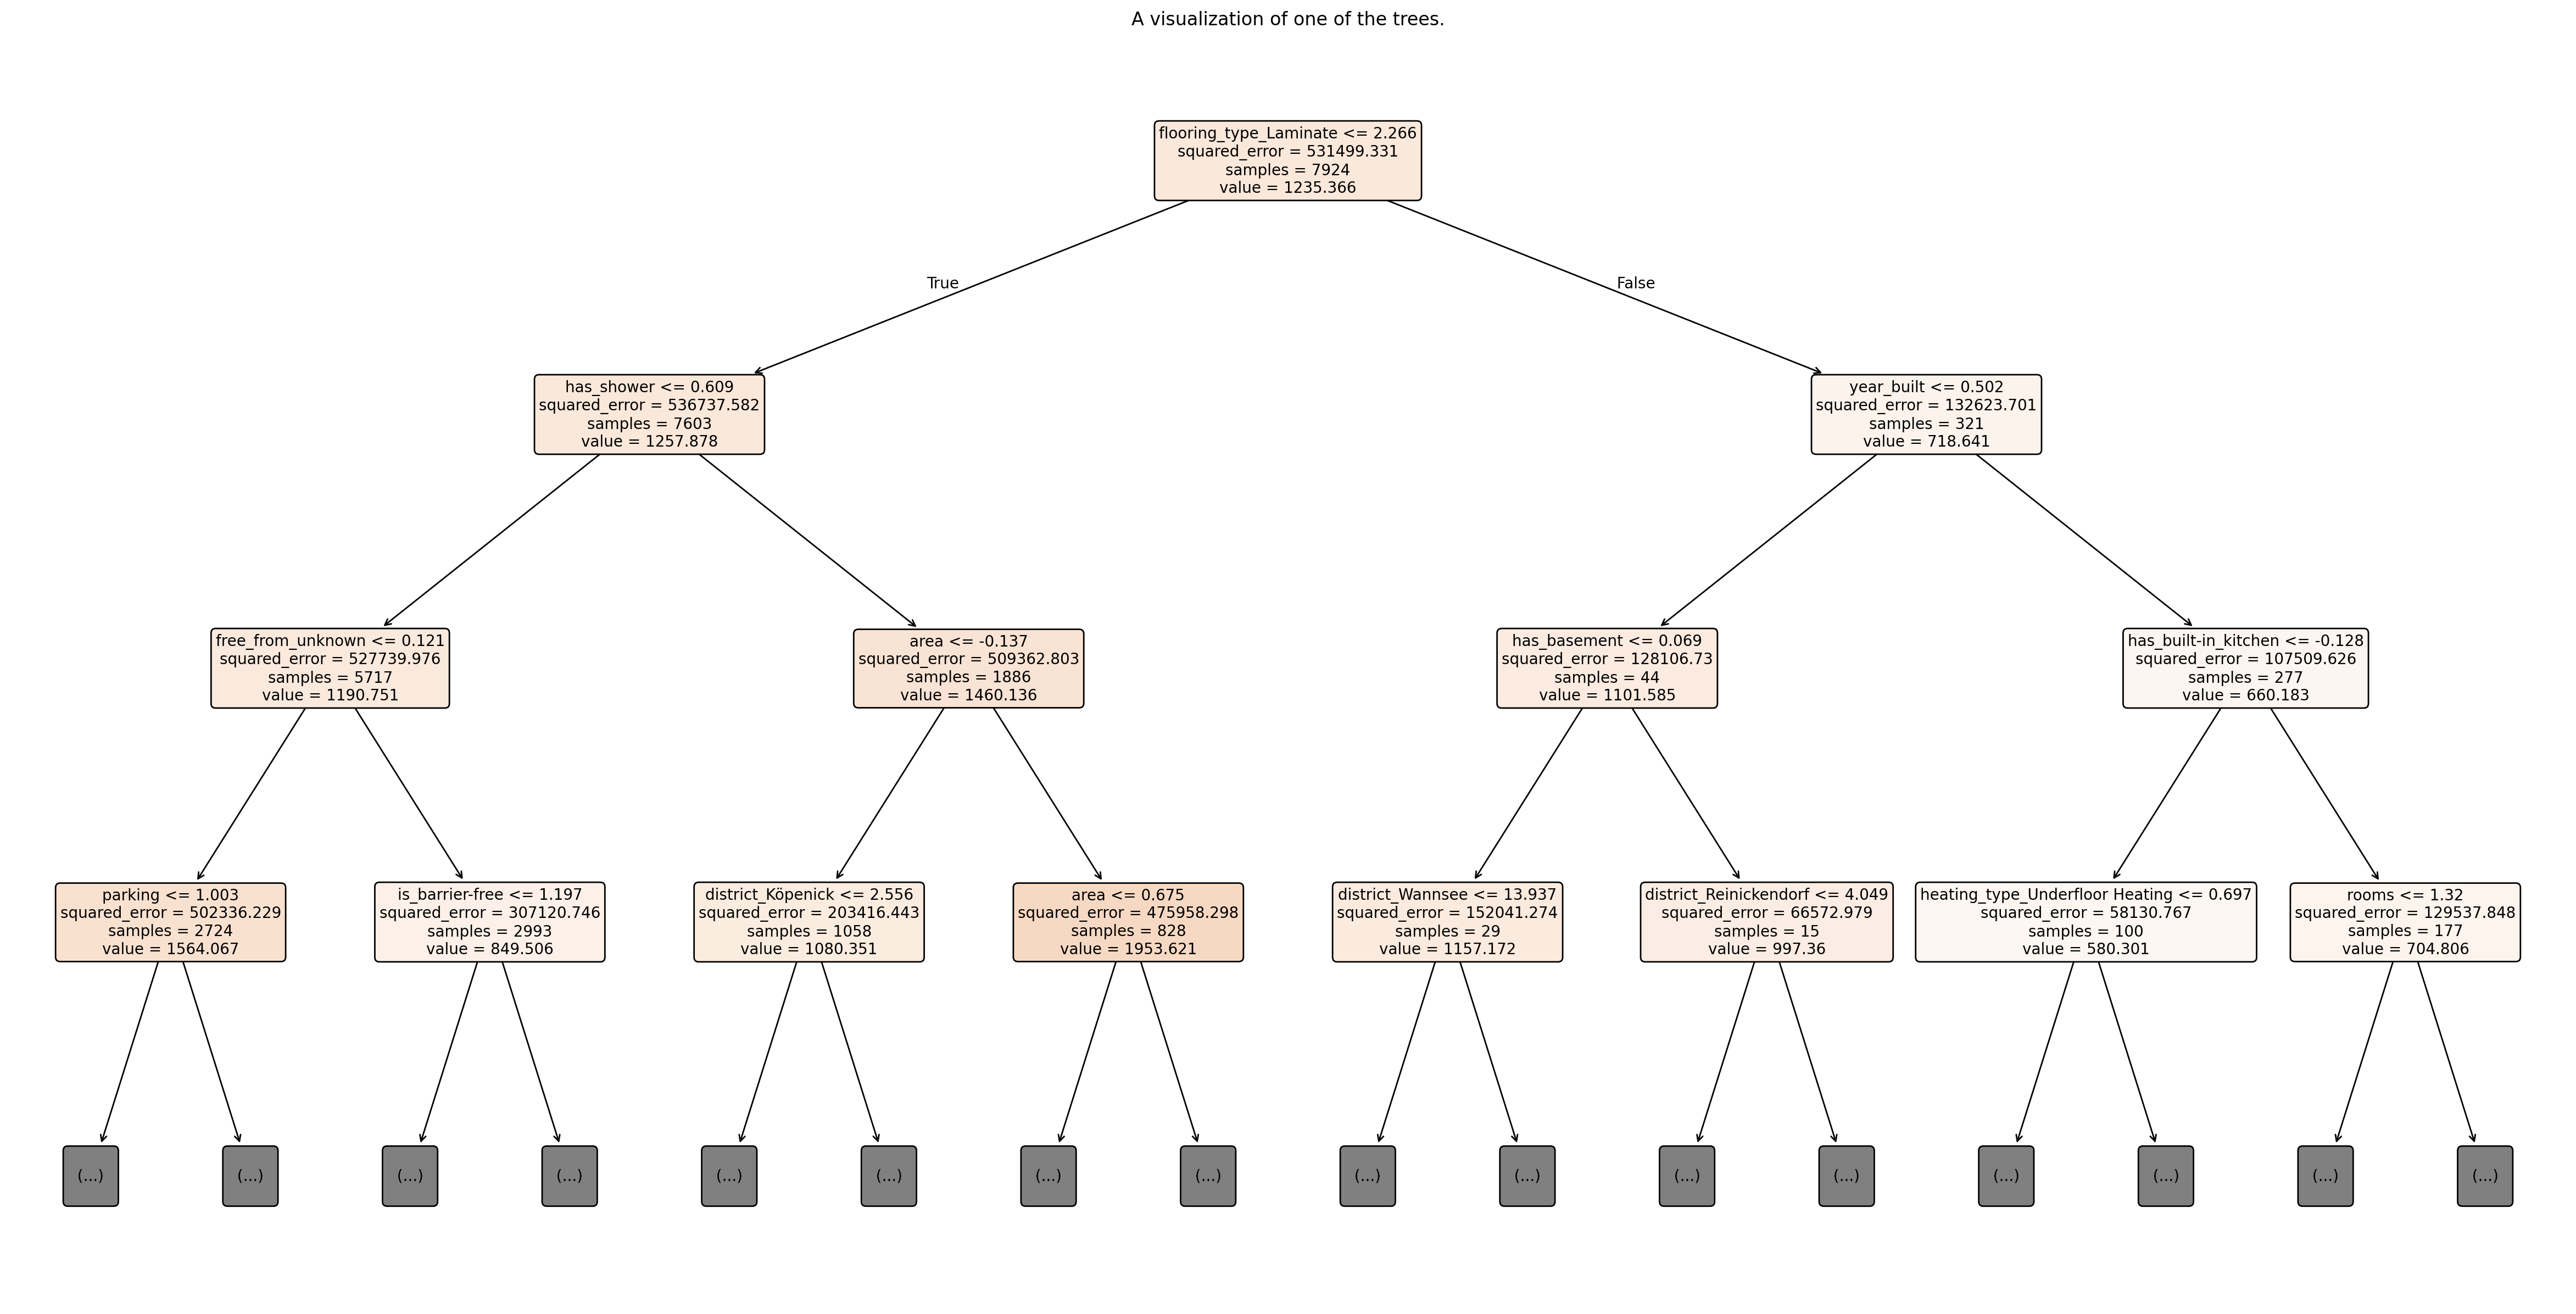

In [48]:
from sklearn.tree import export_graphviz, plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(30, 15), dpi=200)

plot_tree(
    best_model.named_steps["model"].estimators_[16],
    filled=True,
    max_depth=3,
    feature_names=feature_names,
    rounded=True,
    fontsize=10 
)
plt.title("A visualization of one of the trees.")
plt.show()

<span style="font-weight:500">
While a couple of things might seem confusing, like values of thresholds for each split due to standardization or the name of the features used due to encoding, the interpretation of the image becomes unclear. The purpose of this visualization is just to create an idea of how the Random Forest is operating by selecting the best features from a random set of features for each split and computing the best thresholds to minimize the loss. </span>

                                     feature  importance
0                                       area    0.260227
1                                      rooms    0.132474
15                         free_from_unknown    0.072788
13                                year_built    0.058907
39                property_condition_Unknown    0.050774
28                     energy_source_Unknown    0.042247
2                                      floor    0.022883
69                            district_Mitte    0.022057
30           heating_type_Underfloor Heating    0.021198
6                                   elevator    0.019933
12                                has_shower    0.017417
7                                    parking    0.016497
10                      has_built-in_kitchen    0.015918
4                               has_terrasse    0.011835
8                               has_basement    0.010565
20                        flooring_type_Wood    0.010092
3                              

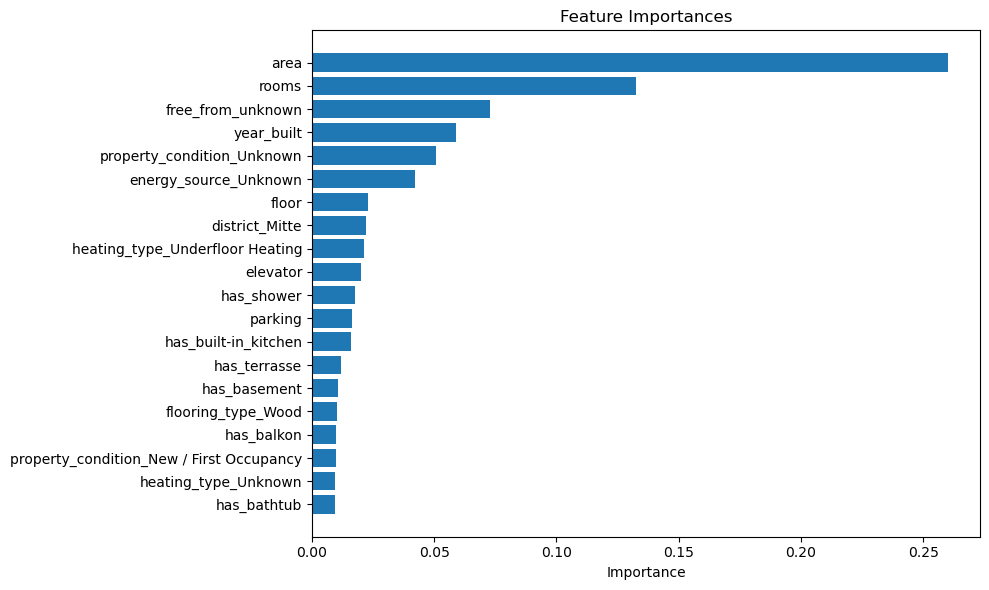

In [50]:
importances = best_model.named_steps["model"].feature_importances_

fi_df = pd.DataFrame({"feature": feature_names, "importance": importances})
fi_df = fi_df.sort_values("importance", ascending=False)

print(fi_df[:20])

plt.figure(figsize=(10, 6))
plt.barh(fi_df["feature"][:20], fi_df["importance"][:20])
plt.gca().invert_yaxis()
plt.title("Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

<span style="font-weight:500">
The graph shows the importance of the features. As we also noticed during Exploratory Data Analysis, the features with the highest importance correspond to the features we concluded had the highest impact, with area having a high importance of 25%, followed by the number of rooms and then the availability of the apartment. By observing this graph, we can gain additional information other than the one we discovered in EDA. For example, we have 'free_from_unknown' as our 3rd feature, with a very relatively high importance. 
<br>
What we notice here is that many unknown categories show up as the top 15 most important features. These could be due to the fact that some of them had high occurrences from 35% to 65% depending on the feature. During EDA we noticed that some of these categories had a really strong meaning and impact on the price, for example "free_from_unknown" making it to the top 3 here, was associated with a huge negative impact on the price.
<br>
One specific category, "Miete" being the 8th most important with 2.2% importance, shows cleaning and working with difficult features like location really pays off and can help with modeling for difficult problems. 
</span>

In [14]:
from xgboost import XGBRegressor

param_grid_xgb = {
    "model__n_estimators": [400, 600],
    "model__max_depth": [5, 7],
    "model__learning_rate": [0.001, 0.01, 0.1],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 3],
    "model__gamma": [0, 0.1]
}

# Model A — With Imputation

pipeline_impute = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(random_state=42, objective="reg:squarederror"))
])

grid_impute = GridSearchCV(
    pipeline_impute,
    param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_impute.fit(X_train, y_train)

best_model_impute = grid_impute.best_estimator_

print("Model A (XGBoost with imputation):")
print("Best params:", grid_impute.best_params_)
print("CV RMSE:", np.sqrt(-grid_impute.best_score_))

y_pred_impute = best_model_impute.predict(X_test)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_impute)))
print("Test R2:", r2_score(y_test, y_pred_impute))
print("Test MAE:", mean_absolute_error(y_test, y_pred_impute))

# Model B — Without Imputation

pipeline_no_impute = Pipeline([
    ("model", XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ))
])

grid_no_impute = GridSearchCV(
    pipeline_no_impute,
    param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_no_impute.fit(X_train, y_train)

best_model_no_impute = grid_no_impute.best_estimator_

print()
print("Model B (XGBoost without imputation):")
print("Best params:", grid_no_impute.best_params_)
print("CV RMSE:", np.sqrt(-grid_no_impute.best_score_))

y_pred_no_impute = best_model_no_impute.predict(X_test)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_no_impute)))
print("Test R2:", r2_score(y_test, y_pred_no_impute))
print("Test MAE:", mean_absolute_error(y_test, y_pred_no_impute))

Model A (XGBoost with imputation):
Best params: {'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__min_child_weight': 3, 'model__n_estimators': 600, 'model__subsample': 0.8}
CV RMSE: 212.8904235561409
Test RMSE: 195.44316703340976
Test R2: 0.9291657552651612
Test MAE: 112.50860599086361

Model B (XGBoost without imputation):
Best params: {'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 7, 'model__min_child_weight': 1, 'model__n_estimators': 600, 'model__subsample': 0.8}
CV RMSE: 213.22053516283677
Test RMSE: 196.07000837411366
Test R2: 0.9287106558292392
Test MAE: 110.4738594543594


<span style="font-weight:500">
XGB is one of the few models that can handle missing values, that is the reason why we tried 2 approaches, one with imputed missing values and one with missing values as they are. Both models perform nearly the same, with the model with imputed values being slightly better. Both of them have a really good performance with an R-squared of almost 0.93, which, considering our data set, is a very good and realistic performance.
<br>
Personally, I thought that XGBoost was going to be the best expected model and most likely this is the model we are going to deploy.
<br>
If you can notice, the hyperparameters of the best-performing model are the highest values, so I would prefer to do another grid search with other values, and in case we get a higher performance, we should also check for overfitting.
</span>

In [13]:
param_grid_xgb = {
    "model__n_estimators": [600, 800],
    "model__max_depth": [9, 11],
    "model__learning_rate": [0.1, 0.5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0],
    "model__min_child_weight": [1, 3],
    "model__gamma": [0, 0.1]
}

# Model A — With Imputation

pipeline_impute = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", XGBRegressor(random_state=42, objective="reg:squarederror"))
])

grid_impute = GridSearchCV(
    pipeline_impute,
    param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_impute.fit(X_train, y_train)

best_model_impute = grid_impute.best_estimator_

print("Model A (XGBoost with imputation):")
print("Best params:", grid_impute.best_params_)
print("CV RMSE:", np.sqrt(-grid_impute.best_score_))

y_pred_impute = best_model_impute.predict(X_test)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_impute)))
print("Test R2:", r2_score(y_test, y_pred_impute))
print("Test MAE:", mean_absolute_error(y_test, y_pred_impute))

# Model B — Without Imputation

pipeline_no_impute = Pipeline([
    ("model", XGBRegressor(
        random_state=42,
        objective="reg:squarederror"
    ))
])

grid_no_impute = GridSearchCV(
    pipeline_no_impute,
    param_grid_xgb,
    cv=5,
    scoring="neg_mean_squared_error",
    n_jobs=-1
)

grid_no_impute.fit(X_train, y_train)

best_model_no_impute = grid_no_impute.best_estimator_

print()
print("Model B (XGBoost without imputation):")
print("Best params:", grid_no_impute.best_params_)
print("CV RMSE:", np.sqrt(-grid_no_impute.best_score_))

y_pred_no_impute = best_model_no_impute.predict(X_test)

print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_no_impute)))
print("Test R2:", r2_score(y_test, y_pred_no_impute))
print("Test MAE:", mean_absolute_error(y_test, y_pred_no_impute))

Model A (XGBoost with imputation):
Best params: {'model__colsample_bytree': 0.8, 'model__gamma': 0.1, 'model__learning_rate': 0.1, 'model__max_depth': 9, 'model__min_child_weight': 1, 'model__n_estimators': 600, 'model__subsample': 1.0}
CV RMSE: 211.83437130461814
Test RMSE: 190.97143642129342
Test R2: 0.9323700425641874
Test MAE: 99.74246486283691

Model B (XGBoost without imputation):
Best params: {'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.1, 'model__max_depth': 9, 'model__min_child_weight': 1, 'model__n_estimators': 600, 'model__subsample': 0.8}
CV RMSE: 211.6443274827569
Test RMSE: 198.73648451087445
Test R2: 0.9267584559913166
Test MAE: 103.71242791280653


<span style="font-weight:500">
We notice a slight improvement by finding similar combinations of hyperparameters. Looking for another combination of hyperparameters is pointless since we ended up with almost the same hyperparameters and the improvement is small.
</span>

In [14]:
y_pred_no_impute_train = best_model_no_impute.predict(X_train)

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_no_impute_train)))
print("Train R2:", r2_score(y_train, y_pred_no_impute_train))
print("Train MAE:", mean_absolute_error(y_train, y_pred_no_impute_train))

Train RMSE: 51.340944444656124
Train R2: 0.9951701756702462
Train MAE: 25.494235073823194


In [15]:
y_pred_impute_train = best_model_impute.predict(X_train)

print("Train RMSE:", np.sqrt(mean_squared_error(y_train, y_pred_impute_train)))
print("Train R2:", r2_score(y_train, y_pred_impute_train))
print("Train MAE:", mean_absolute_error(y_train, y_pred_impute_train))

Train RMSE: 69.70176935419798
Train R2: 0.9910979253217229
Train MAE: 35.31424842844254


<span style="font-weight:500">
If we compare them with the training performance metrics, we notice a difference of R squared of 0.06, which is not small, we are undeniably overfitting and considering XGBoost as an advanced model, overfitting is not uncommon. Considering the difference, the overfitting is not moderate to low and also considering our huge dataset, this level of overfitting is justifiable.
<br>
Let's also run a RepeatedKFold to check stability, if the model is stable, we shouldn't worry.
</span>

In [16]:
from sklearn.model_selection import RepeatedKFold, cross_val_score

best_model = best_model_impute

rkf = RepeatedKFold(
    n_splits=5,     
    n_repeats=3,     
    random_state=16
)

scores = cross_val_score(
    best_model, 
    X_train, 
    y_train,
    scoring='neg_root_mean_squared_error',
    cv=rkf,
    n_jobs=-1
)

rmse_scores = -scores  # make positive

print("Mean RMSE:", np.mean(rmse_scores))
print("Std RMSE:", np.std(rmse_scores))

Mean RMSE: 210.9995524711056
Std RMSE: 15.83557369099962


<span style="font-weight:500">
We have a standard deviation of 15.8, which is not the best we could get (something below 10), but it is also not bad (something above 20). Normally, I would say we are in a gray area, but considering our huge and real dataset, such a score is totally realistic and acceptable.
</span>

In [25]:
y_stability_test = np.array(y_test)

# Create dataframe for grouping
df_last_test = pd.DataFrame({
    "y_true": y_stability_test
})

# Quantile boundaries
low_q = np.quantile(y_test, 0.33)
high_q = np.quantile(y_test, 0.66)

def assign_group(value):
    if value <= low_q:
        return "Low"
    elif value <= high_q:
        return "Medium"
    else:
        return "High"

df_last_test["group"] = df_last_test["y_true"].apply(assign_group)

y_pred = best_model.predict(X_test)

df_last_test["y_pred"] = y_pred

group_results = {}

for group_name in ["Low", "Medium", "High"]:
    mask = df_last_test["group"] == group_name
    
    rmse = np.sqrt(
        mean_squared_error(
            df_last_test.loc[mask, "y_true"],
            df_last_test.loc[mask, "y_pred"]
        )
    )
    
    group_results[group_name] = rmse

print("RMSE by target region:")
for k, v in group_results.items():
    print(f"{k}: {v:.3f}")

RMSE by target region:
Low: 166.490
Medium: 169.581
High: 229.166


<span style="font-weight:500">
The model performs well across low and medium target value regions, with a much higher error in the high-value tail due to data skewness and fewer extreme observations. The model can be considered robust and suitable for prediction purposes. I would say it is a very decent model.
The only future improvements that could be considered include enhancing the accuracy in high-value samples, but that would be the case only if tail prediction were very important for the application and this is not the case.
</span>

In [48]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

def build_nn(input_dim):

    model = models.Sequential()

    model.add(layers.Input(shape=(input_dim,)))

    model.add(layers.Dense(256, activation='relu',
             kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.2))

    model.add(layers.Dense(128, activation='relu',
             kernel_regularizer=tf.keras.regularizers.l2(0.001)))
    model.add(layers.BatchNormalization())
    model.add(layers.Dropout(0.2))

    model.add(layers.Dense(64, activation='relu',
             kernel_regularizer=tf.keras.regularizers.l2(0.001)))

    model.add(layers.Dense(32, activation='relu',
             kernel_regularizer=tf.keras.regularizers.l2(0.001)))

    model.add(layers.Dense(1))  # regression output

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate = 0.0005),
        loss='mse',
        metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )

    return model

In [49]:
nn_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))])

X_train_processed = nn_pipeline.fit_transform(X_train)

X_test_processed = nn_pipeline.transform(X_test)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

nn_model = build_nn(X_train_processed.shape[1])

history = nn_model.fit(
    X_train_processed,
    y_train,
    validation_split=0.2,
    epochs=300,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/300
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1978580.1250 - root_mean_squared_error: 1406.6200 - val_loss: 1678356.3750 - val_root_mean_squared_error: 1295.5138
Epoch 2/300
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 797433.3750 - root_mean_squared_error: 892.9911 - val_loss: 300820.3438 - val_root_mean_squared_error: 548.4703
Epoch 3/300
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 261306.3906 - root_mean_squared_error: 511.1806 - val_loss: 220661.0312 - val_root_mean_squared_error: 469.7448
Epoch 4/300
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 208056.1562 - root_mean_squared_error: 456.1308 - val_loss: 183578.4375 - val_root_mean_squared_error: 428.4596
Epoch 5/300
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 180187.6719 - root_mean_squared_error: 424.4841 - val_loss: 151940.0000 - val_root_mean_squared_error: 389.7937
Epoch 6/300
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 151682.6562 - root_mean_squared_error: 389.4636 - val_loss: 133244.156

In [51]:
y_pred_nn = nn_model.predict(X_test_processed).flatten()

rmse_nn = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2_nn = r2_score(y_test, y_pred_nn)

print("NN RMSE:", rmse_nn)
print("NN R2:", r2_nn)

98/98 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step
NN RMSE: 222.38843364601053
NN R2: 0.9082878918325804


<span style="font-weight:500">
The Neural Network that we modeled performs better than most of the models, but still it doesn't achieve the results of XGBoost. During training we notice that it converges around 180 epochs, so we cannot improve it further unless we model a better NN. 
</span>

In [53]:
y_pred_nn = nn_model.predict(X_train_processed).flatten()

rmse_nn = np.sqrt(mean_squared_error(y_train, y_pred_nn))
r2_nn = r2_score(y_train, y_pred_nn)

print("NN RMSE:", rmse_nn)
print("NN R2:", r2_nn)

390/390 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step  
NN RMSE: 177.84509363965668
NN R2: 0.9420454677769694


<span style="font-weight:500">
Similar to XGBoost it has a moderate to low level of overfitting, so it doesn't have any advantages over XGBoost.
</span>

<span style="color:#42b0f5;font-size:18px;font-weight:500">Part 3: Modeling interpretation and model deployment</span>

In [23]:
best_model

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=0.1, grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=9, max_leaves=None, min_child_weight=1,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=600,
                              n_jobs=None, num_parallel_tree=None, ...))])

In [145]:
import shap

model = best_model.named_steps["model"]

explainer = shap.Explainer(model)

X_test_processed = best_model.named_steps["imputer"].transform(X_test)

shap_values = explainer(X_test_processed)

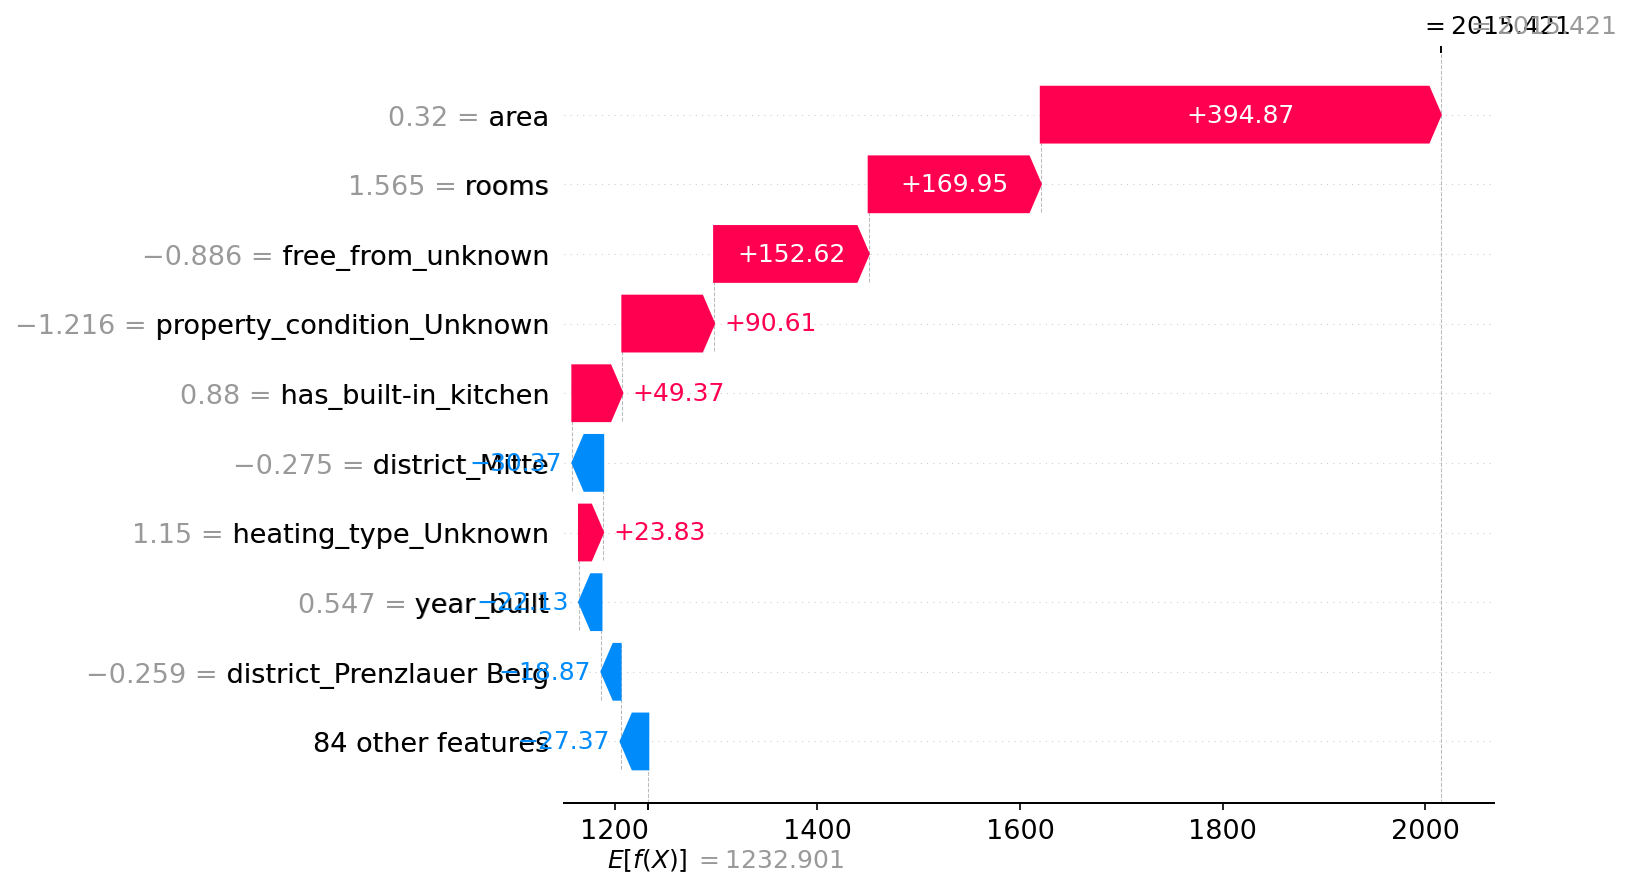

In [147]:
explanation = shap.Explanation(
    values=shap_values.values,
    base_values=shap_values.base_values,
    data=X_test_processed,
    feature_names=feature_names
)

shap.plots.waterfall(explanation[0])

<span style="font-weight:500">
We start with the expected value of the model’s predictions, which is €1232.90. This represents the average predicted rent across all observations, before taking into consideration specific features of a particular apartment.
<br>
Each feature then contributes to shifting this baseline up or down. The feature with the strongest positive contribution is area, which increases the predicted rent by €394.87. The second most influential feature is the number of rooms, which increases the prediction by €169.95.
<br>
After adding all positive feature contributions, the predicted rent increases to €2015.42. Negative feature contributions then reduce this value to approximately €1150.
<br> 
The feature with the strongest negative contribution is the category “Mitte”, which decreases the predicted rent by €30.27, followed by year built, which decreases it by €22.13.
<br>
This ranking has a high similarity with the feature's importance ranking we displayed above. 
</span>

In [152]:
importances = model.feature_importances_

fi_df = (
    pd.DataFrame({"feature": feature_names, "importance": importances})
    .sort_values("importance", ascending=False)
)

print(fi_df.head(10))

                                feature  importance
15                    free_from_unknown    0.144185
69                       district_Mitte    0.042682
0                                  area    0.033537
39           property_condition_Unknown    0.030549
79                  district_Schöneberg    0.030335
80                district_Siemensstadt    0.026657
50                   district_Friedenau    0.023540
33  property_condition_Needs Renovation    0.022501
22               energy_source_Electric    0.020691
28                energy_source_Unknown    0.020405


<span style="font-weight:500">
The importance ranking for our final model does not correspond, which should be expected because they tell us what reduces error, and their role is not for economic interpretation. That is the role of SHAP values, they tell us what moves the predictions.
</span>

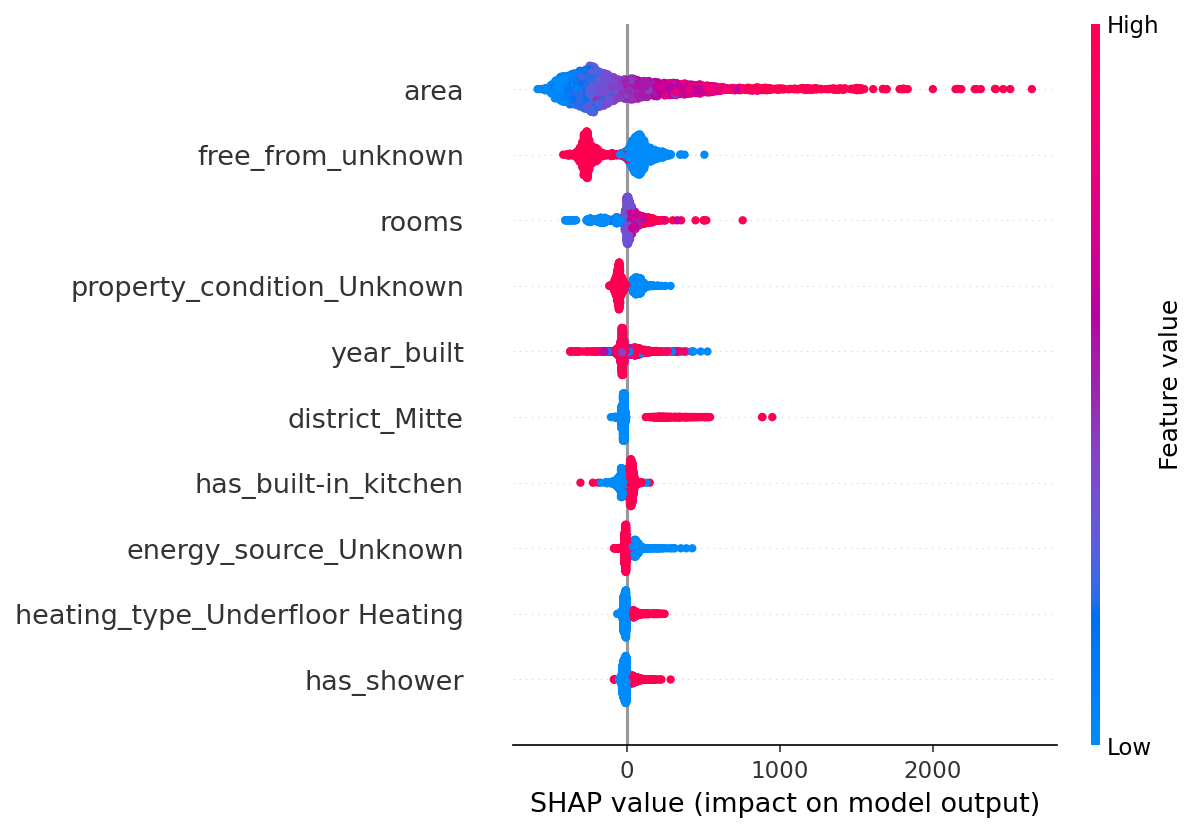

In [167]:
import warnings
warnings.filterwarnings("ignore")
shap.summary_plot(explanation, max_display=10)

<span style="font-weight:500">
This graph is extremely informative and easy to interpret. It shows us which features impact the prices the most and their impact.
<br> 
Features like area and number of rooms are continuous features with a positive contribution, meaning the more we increase them, the more the price increases. 
<br>
Features like free_from_unknown, property_condition_unknown and energy_source_unknown are categorical features that have a positive impact when equal to 1 and lower the prices when they are equal to 0, so when they are not present.
<br>
Year_built is a continuous feature with an inverse effect, meaning with the increase of the feature value, the prices tend to lower, that would mean the older ones tend to have lower prices. In this case, the effect is not very strong and clear but still visible.
<br> 
Categorical features like "district_Mitte", "has_built-in_kitchen", "heating_type_Underfloor Heating" and "has_shower" are features with a positive impact, meaning if present, the price is higher.
</span>

<span style="font-weight:500">
Save our XGBoost model for deployment
</span>

In [225]:
import joblib

joblib.dump(best_model, "best_model.pkl")
joblib.dump(list(X.columns), "col_names.pkl")
joblib.dump(feature_names, "encoded_col_names.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

<span style="font-weight:500">
Load the model.
</span>

In [226]:
best_model = joblib.load("best_model.pkl")
new_cols = joblib.load("col_names.pkl")
encoded_cols = joblib.load("encoded_col_names.pkl")
scaler = joblib.load("scaler.pkl")

In [200]:
best_model

Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None,
                              enable_categorical=False, eval_metric=None,
                              feature_types=None, feature_weights=None,
                              gamma=0.1, grow_policy=None, importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=9, max_leaves=None, min_child_weight=1,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=600,
                              n_jobs=None, num_parallel_tree=None, ...))])

In [201]:
new_cols

['area',
 'rooms',
 'floor',
 'free_from',
 'has_balkon',
 'has_terrasse',
 'has_garten',
 'elevator',
 'parking',
 'has_basement',
 'is_barrier-free',
 'has_built-in_kitchen',
 'has_bathtub',
 'has_shower',
 'flooring_type',
 'energy_source',
 'heating_type',
 'property_condition',
 'year_built',
 'district']

In [202]:
scaler

StandardScaler()

In [227]:
encoded_cols

['area',
 'rooms',
 'floor',
 'has_balkon',
 'has_terrasse',
 'has_garten',
 'elevator',
 'parking',
 'has_basement',
 'is_barrier-free',
 'has_built-in_kitchen',
 'has_bathtub',
 'has_shower',
 'year_built',
 'free_from_not_immediately',
 'free_from_unknown',
 'flooring_type_Laminate',
 'flooring_type_Stone',
 'flooring_type_Tiles',
 'flooring_type_Vinyl',
 'flooring_type_Wood',
 'flooring_type_unknown',
 'energy_source_Electric',
 'energy_source_Gas',
 'energy_source_Heat Pump / Geothermal',
 'energy_source_Hybrid',
 'energy_source_Oil/Coal',
 'energy_source_Other',
 'energy_source_Unknown',
 'heating_type_Individual',
 'heating_type_Underfloor Heating',
 'heating_type_Unit Heating',
 'heating_type_Unknown',
 'property_condition_Needs Renovation',
 'property_condition_New / First Occupancy',
 'property_condition_Old Building',
 'property_condition_Other',
 'property_condition_Partially Renovated',
 'property_condition_Renovated',
 'property_condition_Unknown',
 'property_condition_We

<span style="font-weight:500">
Test a prediction using unseen data, simulating how a user would interact with the model in production.

We evaluated a new rental listing posted on 03/03/2026 with the following characteristics:

Cold rent: 1,990 euro

Apartment size: 83.3 m²

Number of rooms: 4

Floor: 1st floor

Availability: immediately

District: Friedrichsfelde, Berlin

Amenities: built-in kitchen, bathtub, and shower

Construction year: 2025

Additional features: a balcony, terrace, garden, parking, and basement were absent, while an elevator and barrier-free access were available.
</span>

In [230]:
raw_listing = {
    "area": 83.3,
    "rooms": 4,
    "floor": 1,
    "free_from": "immediately",
    "has_balkon": True,
    "has_terrasse": False,
    "has_garten": False,
    "elevator": True,
    "parking": False,
    "has_basement": False,
    "is_barrier-free": True,
    "has_built-in_kitchen": True,
    "has_bathtub": True,
    "has_shower": True,
    "flooring_type": "Unknown",
    "energy_source": "District Heating",
    "heating_type": "Underfloor Heating",
    "property_condition": "New / First Occupancy",
    "year_built": 2025,
    "district": "Friedrichsfelde"
}

new_data = pd.DataFrame([raw_listing])

new_data_encoded = pd.get_dummies(new_data, drop_first=True)

# Align columns to training features
new_data_encoded = new_data_encoded.reindex(columns=encoded_cols, fill_value=0)

# Scale
new_data_scaled = scaler.transform(new_data_encoded)

# Predict
prediction = model.predict(new_data_scaled)

print("Prediction:", prediction[0])

Prediction: 1922.7185


<span style="font-weight:500">
We got an excellent prediction, very close to the original value (1990 euro).
</span>

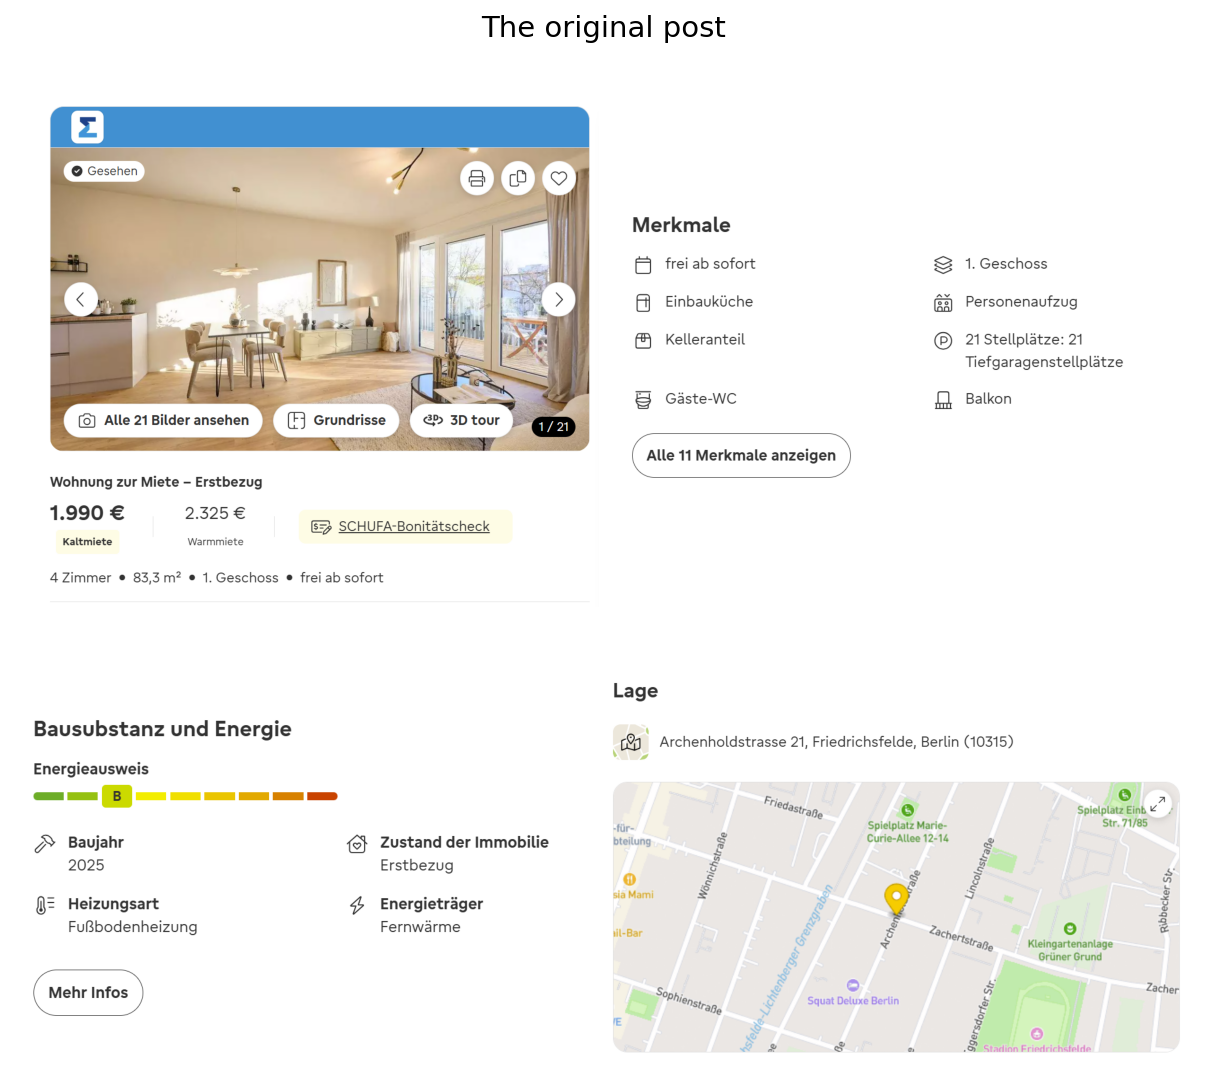

In [235]:
from PIL import Image

images = ["1.png", "2.png", "3.png", "4.png"]

fig, axes = plt.subplots(2, 2, figsize=(8, 8))

for ax, img_path in zip(axes.flatten(), images):
    img = Image.open(img_path)
    ax.imshow(img)
    ax.axis("off")

fig.suptitle("The original post", fontsize=14)

plt.tight_layout()
plt.show()